In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du fichier
df = pd.read_csv("ventes_trendzone.csv", parse_dates=["date"])

# ── Exploration initiale ──────────────────────────────────────────
print("Dimensions :", df.shape)
print("\nTypes de colonnes :")
print(df.dtypes)
print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())
print("\nStatistiques descriptives :")
df.describe()


Dimensions : (500, 13)

Types de colonnes :
transaction_id        str
date                  str
produit               str
categorie             str
quantite            int64
prix_unitaire     float64
remise_pct          int64
vendeur               str
region                str
client_age        float64
client_genre          str
mode_paiement         str
statut                str
dtype: object

Valeurs manquantes par colonne :
transaction_id     0
date               0
produit            0
categorie          0
quantite           0
prix_unitaire      0
remise_pct         0
vendeur            0
region             0
client_age        36
client_genre       0
mode_paiement      0
statut             0
dtype: int64

Statistiques descriptives :


,quantite,prix_unitaire,remise_pct,client_age
count,500.00000,500.000000,500.000000,464.000000
mean,2.00200,72.448800,13.100000,43.885776
std,0.82423,38.714408,13.448112,14.594959
min,0.00000,-59.900000,0.000000,18.000000
25%,1.00000,39.900000,0.000000,31.000000
50%,2.00000,64.900000,10.000000,43.000000
75%,3.00000,89.900000,25.000000,57.000000
max,3.00000,149.900000,40.000000,69.000000


In [2]:
# ── 2.1 Supprimer les doublons ────────────────────────────────────
print("Doublons avant :", df.duplicated(subset="transaction_id").sum())
df = df.drop_duplicates(subset="transaction_id")
print("Doublons après :", df.duplicated(subset="transaction_id").sum())


Doublons avant : 3
Doublons après : 0


In [3]:
# ── 2.2 Corriger les prix négatifs ───────────────────────────────
print("Prix négatifs :", (df["prix_unitaire"] < 0).sum())
df = df[df["prix_unitaire"] > 0]   # on supprime les lignes incohérentes


Prix négatifs : 2


In [4]:
# ── 2.3 corriger les quantités nulles  ───────────────────────────
print("quantités nulles :", (df["quantite"] == 0).sum())
df = df[df["quantite"] > 0] # on supprime les lignes incohérentes

quantités nulles : 1


In [5]:
print("Après nettoyage :", (df["quantite"] == 0).sum())

Après nettoyage : 0


In [6]:
# ── 2.4 Traiter les valeurs manquantes de client_age ─────────────
# Stratégie : remplacer par la médiane (plus robuste que la moyenne)

mediane_age = df["client_age"].median()
print("Médiane âge :", mediane_age)

df["client_age"] = df["client_age"].fillna(mediane_age)

print("Valeurs manquantes restantes :", df["client_age"].isna().sum())

Médiane âge : 43.0
Valeurs manquantes restantes : 0


In [7]:
# Dates invalides
parsed = pd.to_datetime(df["date"], errors="coerce")
invalid_dates = df.loc[parsed.isna(), "date"].unique()

print(invalid_dates)

<StringArray>
['03/02/2025', '2025/01/28', '15-04-2025', '22.03.2025', '01/05/2025']
Length: 5, dtype: str


In [8]:
df["date"] = df["date"].astype(str).str.replace(r"[./]", "-", regex=True)

df["date"] = pd.to_datetime(df["date"], format="mixed", errors="coerce")
df["date"] = df["date"].dt.strftime("%Y-%m-%d")


In [9]:
# Verifier le format final YYYY-MM-DD
print(df["date"].head())

0    2025-02-21
1    2025-02-19
2    2025-04-12
3    2025-04-02
4    2025-01-27
Name: date, dtype: str


In [10]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["date"] = df["date"].dt.strftime("%Y-%m-%d")

In [11]:
# Dates invalides
invalid_dates = df.loc[parsed.isna(), "date"].unique()

print(invalid_dates)

<StringArray>
['2025-03-02', '2025-01-28', '2025-04-15', '2025-03-22', '2025-01-05']
Length: 5, dtype: str


In [12]:
# séparer les lignes

parties = {
    "lignes_50_51": df.iloc[49:51],
    "lignes_100_101": df.iloc[99:101],
    "lignes_150_151": df.iloc[149:151],
    "lignes_200_201": df.iloc[199:201],
    "lignes_400_401": df.iloc[399:401],
    "lignes_449_450": df.iloc[448:450],
    "lignes_499_500": df.iloc[498:500],
}

In [13]:
df["date"] = pd.to_datetime(df["date"], errors="coerce") 

# Ajouter des colonnes calculées
df["chiffre_affaires"] = df["quantite"] * df["prix_unitaire"] * (1 - df["remise_pct"]/100)
df["mois"] = df["date"].dt.month
df["mois_nom"] = df["date"].dt.strftime("%b")
df["trimestre"] = df["date"].dt.quarter

In [14]:
# pour exporter le fichier corrigé en csv
df.to_csv("ventes_trendzone_corrige.csv", index=False, encoding="utf-8-sig")

In [15]:
# Chargement du fichier
df = pd.read_csv('ventes_trendzone_corrige.csv')

In [16]:

# ── Q1 : Évolution du CA mensuel ─────────────────────────────────
ca_mensuel = df.groupby("mois_nom")["chiffre_affaires"].sum().reset_index()


In [17]:
# Réordonner les mois chronologiquement
ordre_mois = ["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"]

In [18]:
# Réordonner les mois chronologiquement sur le graphique
ordre_mois = ["Jan", "Feb", "Mar", "Apr"]

ca_mensuel["mois_nom"] = pd.Categorical(
    ca_mensuel["mois_nom"],
    categories=ordre_mois,
    ordered=True
)

ca_mensuel = ca_mensuel.sort_values("mois_nom")

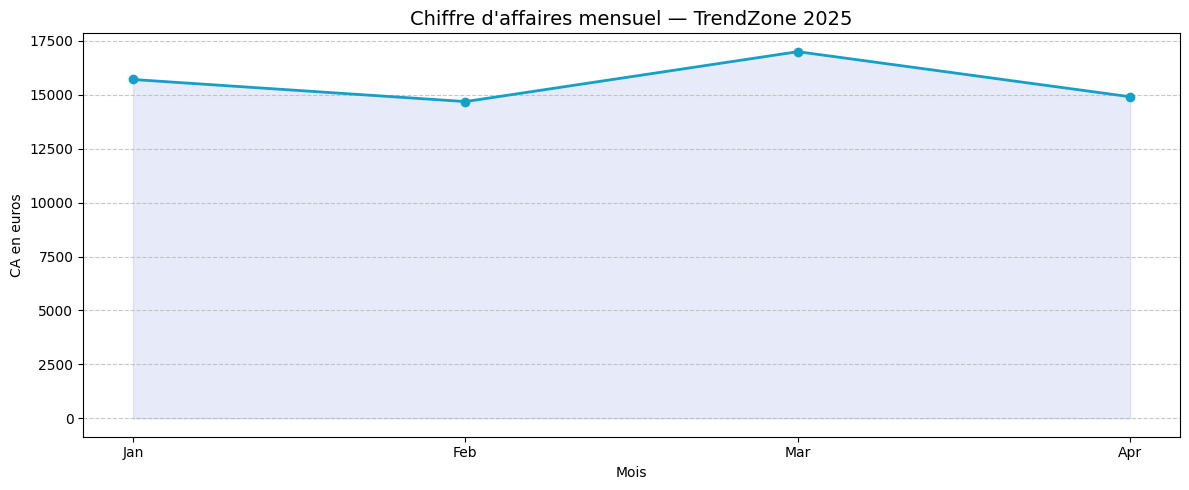

In [19]:

plt.figure(figsize=(12, 5))
plt.plot(ca_mensuel["mois_nom"], ca_mensuel["chiffre_affaires"],
         marker="o", color="#15A0CA", linewidth=2)
plt.fill_between(range(len(ca_mensuel)), ca_mensuel["chiffre_affaires"],
                 alpha=0.1, color="#153FCA")
plt.title("Chiffre d'affaires mensuel — TrendZone 2025", fontsize=14)
plt.xlabel("Mois")
plt.ylabel("CA en euros")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Interprétation à écrire en Markdown sous cette cellule :
# "Le CA atteint son pic en Mars tandis que Février est le plus faible .La tendance générale est plutôt stable sur la période, avec des variations modérées d’un mois à l’autre. 


Le CA atteint son pic en Mars tandis que Février est le plus faible .La tendance générale est plutôt stable sur la période, avec des variations modérées d’un mois à l’autre. 

In [20]:
# ── Q2 : Variation du CA par produit ─────────────────────────────────
cat_col = "categorie"
ca_col = "chiffre_affaires"
ca_cat = df.groupby(cat_col)[ca_col].sum().reset_index()


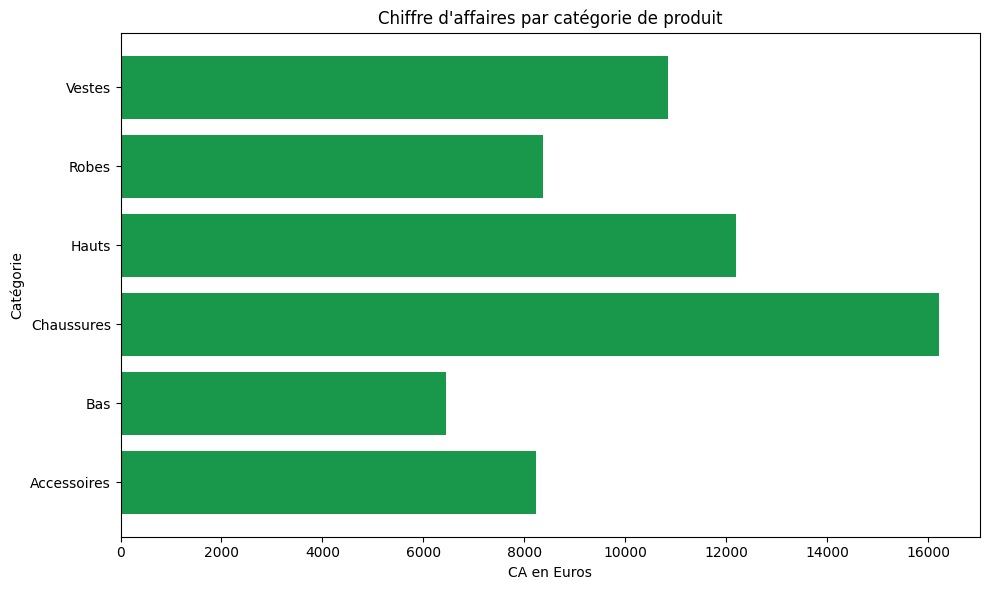

In [21]:
plt.figure(figsize=(10,6))
plt.barh(ca_cat[cat_col], ca_cat[ca_col], color="#19974A")
plt.title('Chiffre d\'affaires par catégorie de produit')
plt.xlabel("CA en Euros")
plt.ylabel('Catégorie')
plt.tight_layout()
plt.show()

Le graphique montre que le chiffre d’affaires est dominé par la catégorie Chaussures (avec +de 16000 euros de vente), suivie des Hauts, ce qui indique une forte demande pour ces produits. En revanche, la catégorie Bas est la moins performante. 

In [22]:
df = pd.read_csv("ventes_trendzone_corrige.csv")

In [23]:
# ── Q3 : Variation du CA par région ─────────────────────────────────
ca_region = df.groupby("region")["chiffre_affaires"].sum().sort_values(ascending=False).reset_index()

In [24]:
print(ca_region.head())


       region  chiffre_affaires
0   Marseille          8705.815
1       Paris          7829.450
2      Nantes          7222.595
3  Strasbourg          7049.415
4        Lyon          6643.765


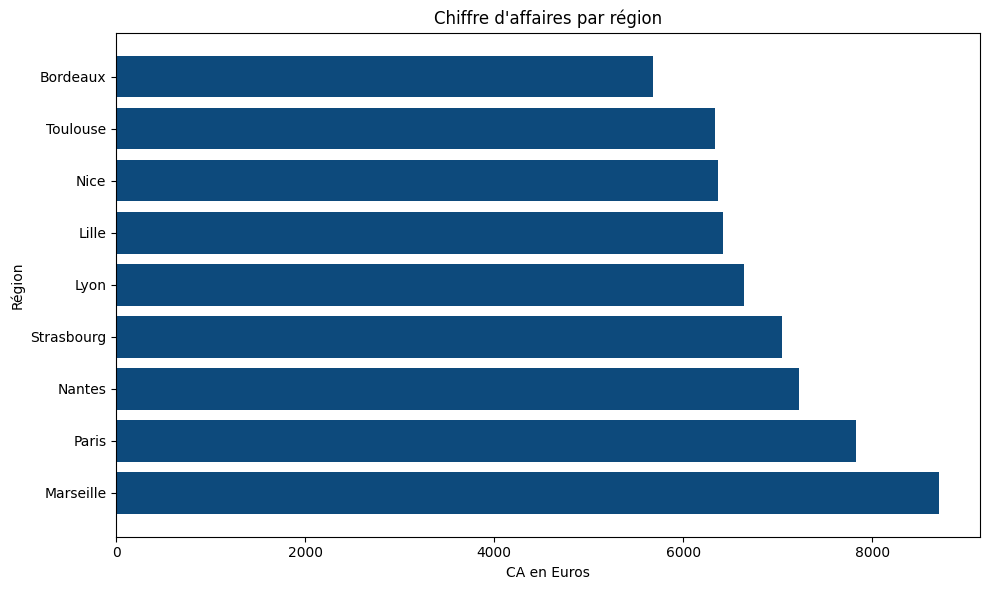

In [25]:
plt.figure(figsize=(10,6))

ca_col = "chiffre_affaires"
region_col = "region"
plt.barh(ca_region[region_col], ca_region[ca_col], color="#0D4A7C")
plt.title('Chiffre d\'affaires par région')
plt.xlabel("CA en Euros")
plt.ylabel('Région')
plt.tight_layout()
plt.show()


La région la plus performante est Marseille, avec le chiffre d’affaires le plus élevé (plus de 8000 Euros). Bordeaux enregistre le chiffre d’affaire le plus faible. 

In [26]:
# ── Q4 : Profil des meilleurs clients ─────────────────────────────────
age_col = "client_age"
genre_col = "client_genre"
ca_col = "chiffre_affaires"

profil = (
    df.groupby("client_age", "client_genre")["chiffre_affaires"]
      .sum()
      .reset_index()
      .sort_values(ca_col, ascending=False)
)

ValueError: level name client_genre is not the name of the index